# Visualizacion inicial de VinDr
Este notebook usa la funcion de `image` para listar y visualizar mamografias DICOM del dataset VinDr.

In [14]:
import sys
import random
import pydicom
from pathlib import Path


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from image.visualization import list_dicom_images, show_dicom_image

## Laptop
DEFAULT_VINDR_IMAGES_DIR = Path('/home/eloygarcia/Escritorio/Datasets/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/')

## Definitions
BACKEND = 'np_v1'

In [15]:
print(DEFAULT_VINDR_IMAGES_DIR)

/home/eloygarcia/Escritorio/Datasets/vinDr/physionet.org/files/vindr-mammo/1.0.0/images


In [16]:
dicom_paths = list_dicom_images(DEFAULT_VINDR_IMAGES_DIR, recursive=True)

idx = random.randint(0, len(dicom_paths)-1)

print(f'Total de imagenes DICOM: {len(dicom_paths)}')
print(f'Imagen: {dicom_paths[idx].name}')
print(f'Index: {idx}')

Total de imagenes DICOM: 78
Imagen: 8a07d099fdc4ffd84cbda873b72f461d.dicom
Index: 71


## Metadatos y preprocesado
Esta seccion muestra una mamografia tras aplicar windowing y segmentacion de fondo, junto con una superposicion de la mascara sobre la imagen original.

In [17]:
import matplotlib.pyplot as plt

from image.preprocessing import (
    apply_background_mask,
    # apply_windowing,
    load_dicom_pixels,
    read_dicom_metadata,
    segment_breast_region,
 )

from image.apply_windowing import *
from image.calculate_windowing import(
    get_dicom_voi_lut_params, 
    calculate_windowing, 
    should_invert_monochrome1, 
    normalize_photometric,
)


In [18]:
## Imagen de lista
image_path = list_dicom_images(DEFAULT_VINDR_IMAGES_DIR, recursive=True)[idx]

### metadata <==> dcm
metadata = pydicom.dcmread(image_path)
print(metadata)

original_image = metadata.pixel_array

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 158
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Digital Mammography X-Ray Image Storage - For Presentation
(0002,0003) Media Storage SOP Instance UID      UI: 8a07d099fdc4ffd84cbda873b72f461d
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.3.4
(0002,0013) Implementation Version Name         SH: 'RadiAnt-2020.1.1'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: 8a07d099fdc4ffd84cbda873b72f461d
(0008,0060) Modality                            CS: 'MG'
(0008,0068) Presentation Intent Type            CS: 'FOR PRESENTATION'
(0008,0070) Manufacturer                        LO: 'SIEMENS'
(0008,1090) Manufacturer's Model Name           LO: 'Mammomat Inspiration'
(0010,0040) Patient's Sex

/home/eloygarcia/anaconda3/envs/GeoSpatial/lib/python3.14/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '8a07d099fdc4ffd84cbda873b72f461d'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/home/eloygarcia/anaconda3/envs/GeoSpatial/lib/python3.14/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '00dfcde5aaf6cd0aab3c3a0435632b3f'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/home/eloygarcia/anaconda3/envs/GeoSpatial/lib/python3.14/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'a24e719d5131cb4883f014f096e077d1'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


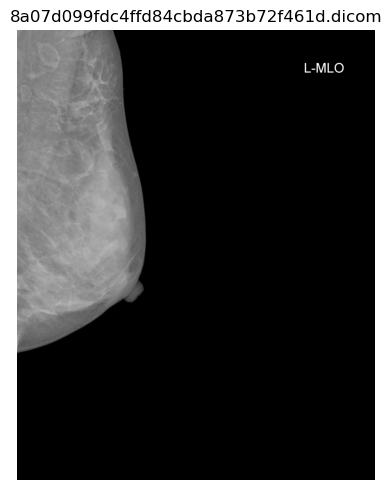

In [19]:
# figure, axis, image = show_dicom_image(image_index=idx)
figsize = (5, 5)

figure, axis = plt.subplots(figsize=figsize)
axis.imshow(original_image, cmap='gray')
axis.set_title(dicom_paths[idx].name)
axis.axis("off")
figure.tight_layout()

In [20]:
## Creo que normalize photometric ya hace la comprobación de si hay que invertir o no, pero por si acaso lo dejo
print(should_invert_monochrome1(metadata) )

#if should_invert_monochrome1(metadata):
original_image, _ = normalize_photometric(original_image, metadata)

False


## Windowing

In [21]:

voilut = get_dicom_voi_lut_params(metadata)
print(voilut)

windowed_image = apply_windowing(original_image,
                                 window_width = voilut['window_width'],
                                 window_center = voilut['window_center'],
                                 voi_func = voilut['voi_lut_function'],
                                 y_min = original_image.min(),
                                 y_max =  original_image.max(), 
                                 backend = 'np_v2')

{'window_center': 1679, 'window_width': 1500, 'rescale_intercept': 0.0, 'rescale_slope': 1.0, 'voi_lut_function': 'LINEAR'}


(0008,0018): (0008,0018) SOP Instance UID                    UI: 8a07d099fdc4ffd84cbda873b72f461d
(0008,0060): (0008,0060) Modality                            CS: 'MG'
(0008,0068): (0008,0068) Presentation Intent Type            CS: 'FOR PRESENTATION'
(0008,0070): (0008,0070) Manufacturer                        LO: 'SIEMENS'
(0008,1090): (0008,1090) Manufacturer's Model Name           LO: 'Mammomat Inspiration'
(0010,0040): (0010,0040) Patient's Sex                       CS: 'F'
(0010,1010): (0010,1010) Patient's Age                       AS: '043Y'
(0018,0015): (0018,0015) Body Part Examined                  CS: 'BREAST'
(0018,1164): (0018,1164) Imager Pixel Spacing                DS: [0.085, 0.085]
(0018,5101): (0018,5101) View Position                       CS: 'MLO'
(0020,000D): (0020,000D) Study Instance UID                  UI: 00dfcde5aaf6cd0aab3c3a0435632b3f
(0020,000E): (0020,000E) Series Instance UID                 UI: a24e719d5131cb4883f014f096e077d1
(0020,0062): (0020,0062

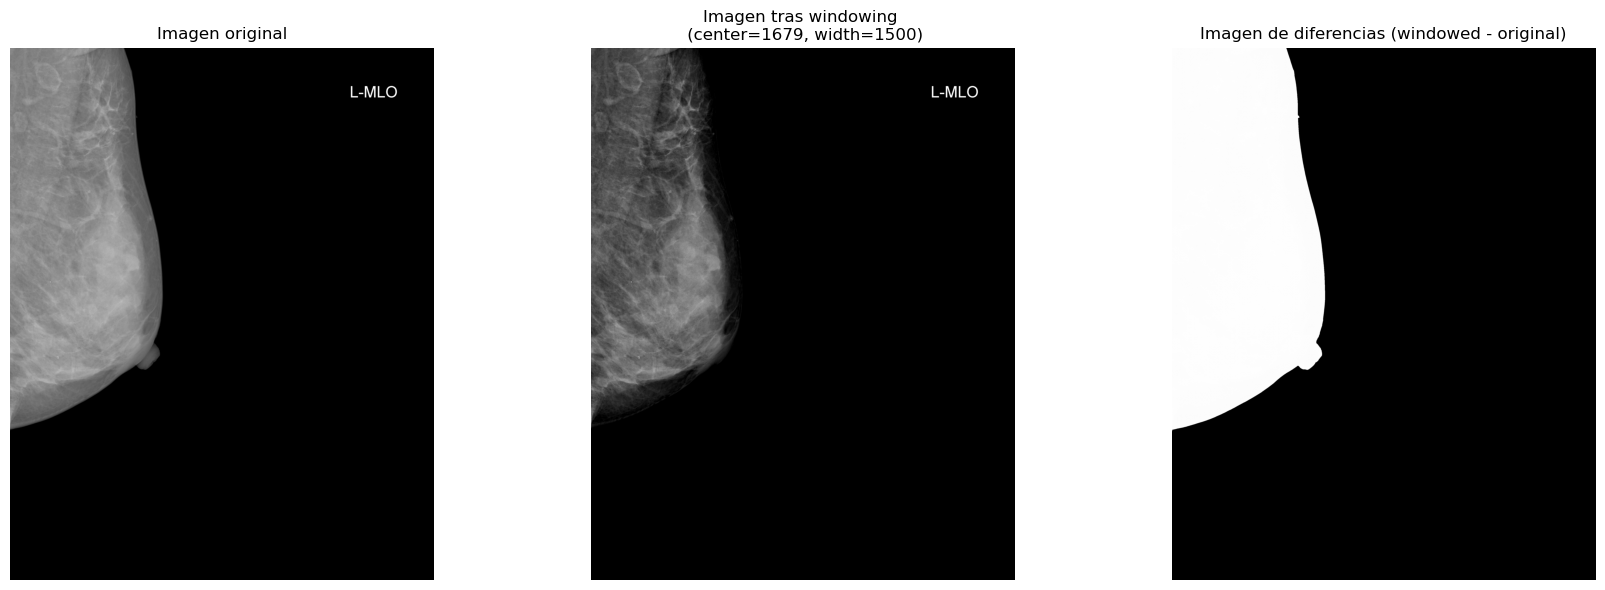

In [22]:
figure, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(windowed_image, cmap='gray')
#axes[1].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[1].set_title(f'Imagen tras windowing \n (center={voilut["window_center"]}, width={voilut["window_width"]})')
axes[1].axis('off')

axes[2].imshow(windowed_image - original_image, cmap='gray')
#axes[2].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[2].set_title('Imagen de diferencias (windowed - original)')
axes[2].axis('off')

figure.tight_layout()

visible_metadata = {
    key: value
    for key, value in metadata.items()
    if value not in (None, '', [], {})
}

for key, value in visible_metadata.items():
    print(f'{key}: {value}')

## Incluir localización del pecho

In [ ]:
## TODO

import csv
import pandas as pd

INBREAST_CSV = Path('/home/eloygarcia/Escritorio/Datasets/INbreast/INBreast_breast_region.csv')

# Load CSV into a list of dicts
#with INBREAST_CSV.open(newline='', encoding='utf-8') as f:
#    records = list(csv.DictReader(f))
records = pd.read_csv(INBREAST_CSV)#.to_dict(orient='records')

print(f"Total annotations: {len(records)}")
print("Sample row:", records.iloc[0])

Total annotations: 410
Sample row: file_name    AllDICOMs/20586908_6c613a14b80a8591_MG_R_CC_AN...
bboxes       [1348.1292724609375, 34.610595703125, 3311.559...
scores                                                0.988837
Name: 0, dtype: object
